# 第一版模型交接演示
从本目录启动 Jupyter，按顺序运行。这里使用 CPU 整数参考，硬件尚未连接。

In [1]:
from pathlib import Path
import json
import numpy as np
from PIL import Image
from integer_inference import IntegerDigitCNN
from preprocess import preprocess_digit_image
model = IntegerDigitCNN.from_directory()
print("Loaded digitcnn_v1_int8")

Loaded digitcnn_v1_int8


In [2]:
inputs = np.load("release/reference/fixed_inputs_uint8.npy", allow_pickle=False)
result = model.forward(inputs, return_layers=True)
print("预测：", result.predictions.tolist())
assert result.predictions.tolist() == list(range(10))

预测： [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


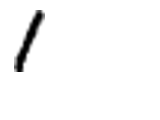

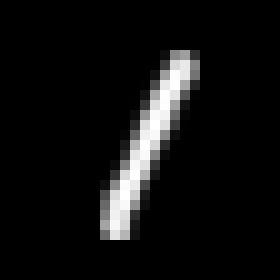

数字： 1
原始 int32 分数： [-25052  15776  -3625 -13068 -17985 -29175 -24344 -10668  -8516 -23528]


In [3]:
sample = sorted(Path("examples").glob("*.png"))[0]
prepared = preprocess_digit_image(sample)
result = model.forward(prepared.normalized_uint8)
display(Image.open(sample))
display(Image.fromarray(prepared.normalized_uint8).resize((280,280), Image.Resampling.NEAREST))
print("数字：", int(result.predictions[0]))
print("原始 int32 分数：", result.scores_int32[0])

validation float: 0.9502 int8: 0.9486
official_test float: 0.953 int8: 0.9521
synthetic_camera_like float: 0.944 int8: 0.941


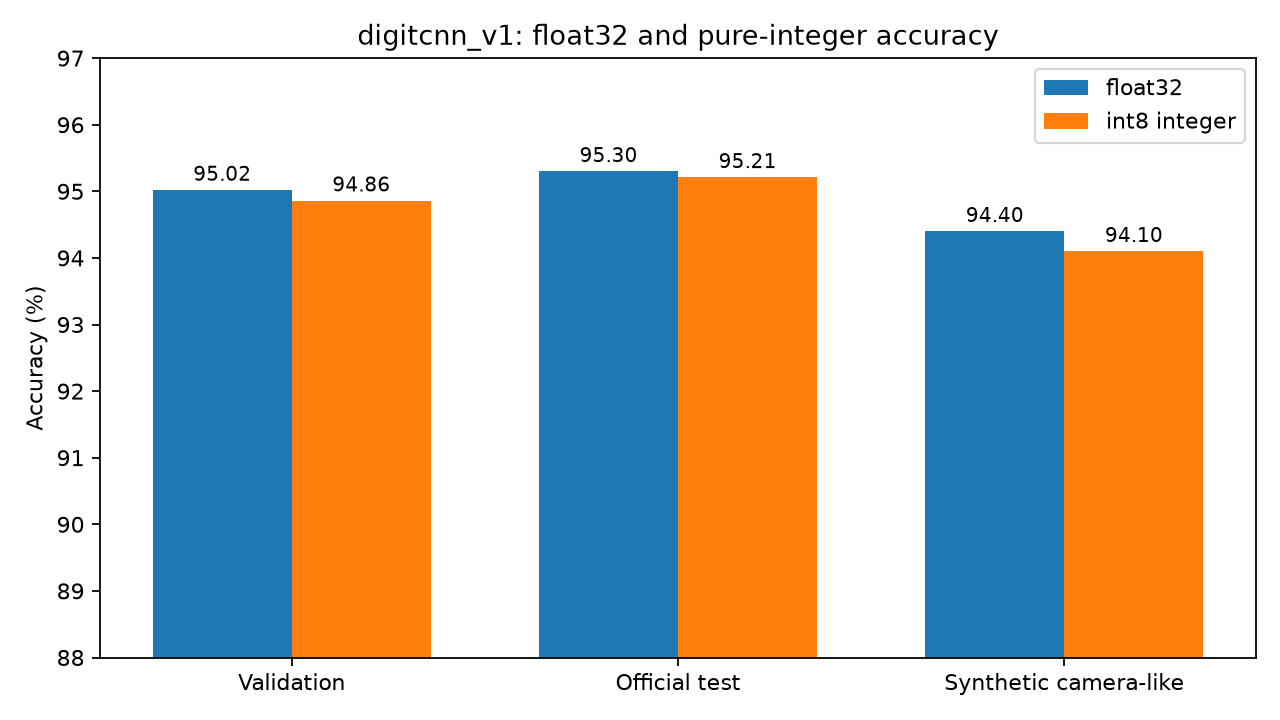

In [4]:
summary = json.loads(Path("release/evaluation/summary.json").read_text(encoding="utf-8"))
for name, entry in summary["results"].items():
    print(name, "float:", entry["float_accuracy"], "int8:", entry["int8_accuracy"])
display(Image.open("release/evaluation/accuracy_comparison.png"))

下一步：A 阅读 docs/FOR_A.md；C 阅读 docs/FOR_C.md。AXI 协议仍是草案，未创建或测试 Overlay。